In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
df = pd.read_csv('battery_V5.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


#
### **🚧 4. 혼잡 / 경로 / 충돌**
* congestion_score → 창고 혼잡도 점수
* max_zone_density → 특정 구역 최대 밀집도
* blocked_path_15m → 막힌 경로 수 (15분)
* near_collision_15m → 충돌 직전 이벤트 수
* aisle_traffic_score → 통로 교통량 점수
* intersection_wait_time_avg → 교차로 평균 대기 시간
* path_optimization_score → 경로 최적화 점수

In [ ]:
traffic = df[["congestion_score","max_zone_density","blocked_path_15m",
        "near_collision_15m","aisle_traffic_score",
        "intersection_wait_time_avg","path_optimization_score"]]
traffic

,congestion_score,max_zone_density,blocked_path_15m,near_collision_15m,aisle_traffic_score,intersection_wait_time_avg,path_optimization_score
0,0.0,0.0,0.0,NaN,24.4,1.51,77.2
1,0.0,0.0,0.0,0.0,15.8,1.77,81.5
2,0.0,0.0,NaN,0.0,38.0,2.06,64.5
3,0.0,NaN,0.0,0.0,18.6,1.08,64.6
4,0.0,0.0,0.0,0.0,22.7,0.34,73.6
...,...,...,...,...,...,...,...
249995,0.0,0.0,0.0,0.0,11.9,1.78,74.0
249996,0.0,0.0,NaN,0.0,26.5,0.93,81.1
249997,0.0,0.0,0.0,0.0,34.1,1.25,79.8
249998,0.0,0.0,0.0,0.0,25.8,0.00,85.1


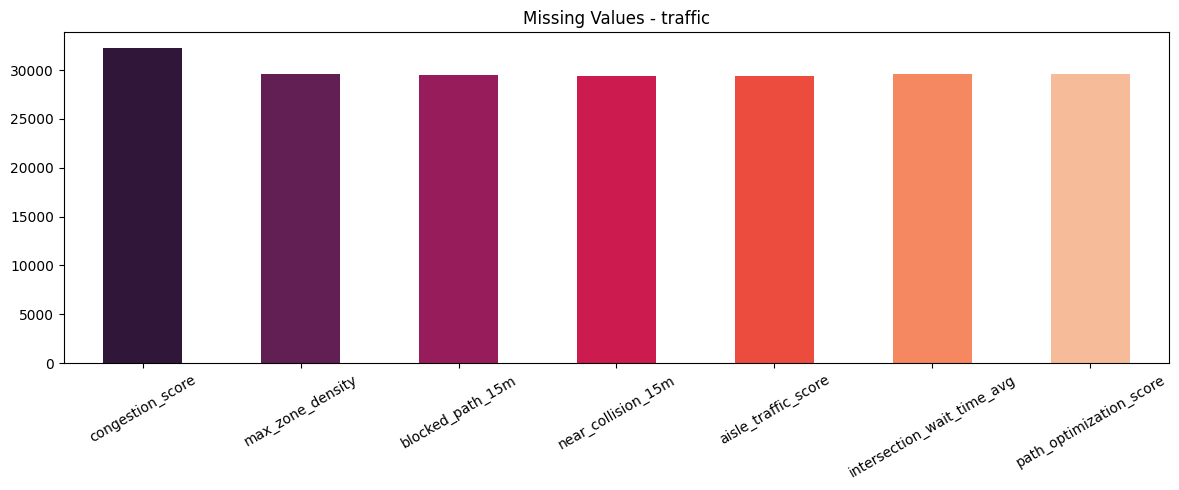

In [ ]:
missing = traffic.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - traffic')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**
congestion_score ↔ blocked_path_15m = **0.83**  
⇒ 경로가 많이 막힐수록 전체 혼잡도가 크게 증가  

congestion_score ↔ max_zone_density = **0.76**  
⇒ 특정 구역 밀집도가 높을수록 혼잡 증가  

congestion_score ↔ near_collision_15m = **0.73**  
⇒ 충돌 위험 이벤트 증가 = 혼잡 증가

blocked_path_15m ↔ near_collision_15m = 0.66  
⇒ 경로 막힘이 많을수록 충돌 위험 증가

max_zone_density ↔ blocked_path_15m = 0.63  
⇒ 밀집도 ↑ → 경로 차단 ↑

max_zone_density ↔ near_collision_15m = 0.61  
⇒ 밀집된 환경에서 충돌 위험 증가

In [ ]:
corr = traffic.corr()
corr

,congestion_score,max_zone_density,blocked_path_15m,near_collision_15m,aisle_traffic_score,intersection_wait_time_avg,path_optimization_score
congestion_score,1.000000,0.764568,0.833763,0.727144,0.468492,0.292710,-0.039259
max_zone_density,0.764568,1.000000,0.626846,0.613010,0.350786,0.215010,-0.048180
blocked_path_15m,0.833763,0.626846,1.000000,0.656706,0.390714,0.348390,-0.025357
near_collision_15m,0.727144,0.613010,0.656706,1.000000,0.343174,0.228085,-0.025605
aisle_traffic_score,0.468492,0.350786,0.390714,0.343174,1.000000,0.130454,-0.017250
intersection_wait_time_avg,0.292710,0.215010,0.348390,0.228085,0.130454,1.000000,-0.026296
path_optimization_score,-0.039259,-0.048180,-0.025357,-0.025605,-0.017250,-0.026296,1.000000


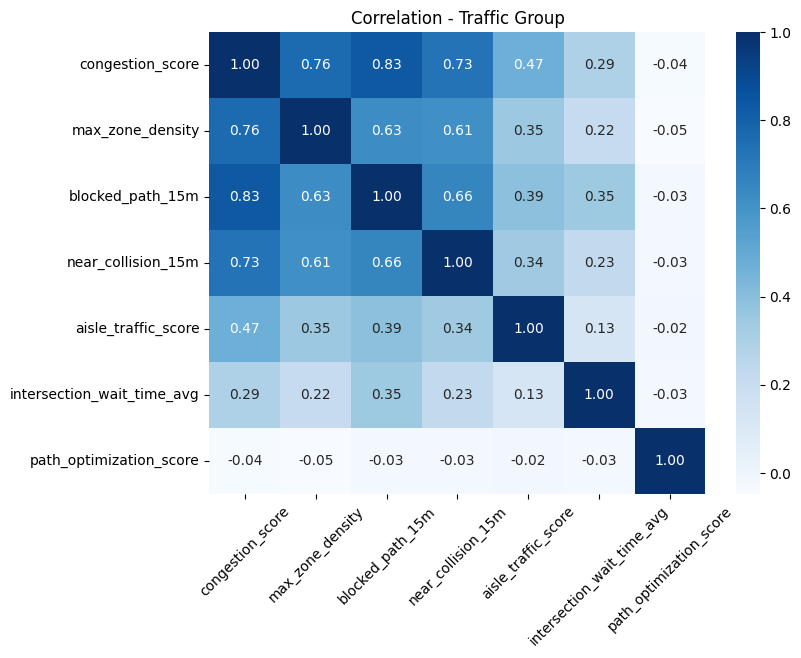

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Traffic Group')
plt.xticks(rotation=45)
plt.show()

###
### **결측치 채우기**
#### train datasets
congestion_score ↔ blocked_path_15m = **0.83**  

congestion_score ↔ max_zone_density = **0.76**  

congestion_score ↔ near_collision_15m = **0.73**  

In [ ]:
traffic[["congestion_score", "max_zone_density", "blocked_path_15m", "near_collision_15m"]]

,congestion_score,max_zone_density,blocked_path_15m,near_collision_15m
0,0.0,0.0,0.0,NaN
1,0.0,0.0,0.0,0.0
2,0.0,0.0,NaN,0.0
3,0.0,NaN,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
249995,0.0,0.0,0.0,0.0
249996,0.0,0.0,NaN,0.0
249997,0.0,0.0,0.0,0.0
249998,0.0,0.0,0.0,0.0


####
* 모두 결측인 경우

In [ ]:
traffic[
    traffic["congestion_score"].isna() &
    traffic[["blocked_path_15m", "max_zone_density", "near_collision_15m"]].isna().all(axis=1)
].shape[0]

56

In [ ]:
# 모두 결측인 경우 삭제
traffic = traffic[~(
    traffic["congestion_score"].isna() &
    traffic[["blocked_path_15m", "max_zone_density", "near_collision_15m"]]
    .isna().all(axis=1)
)]
traffic.shape[0]

249944

In [ ]:
# 모두 결측인 경우 삭제
df = df[~(
    df["congestion_score"].isna() &
    df[["blocked_path_15m", "max_zone_density", "near_collision_15m"]]
    .isna().all(axis=1)
)]
df.shape[0]

249944

In [ ]:
traffic[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,32194
blocked_path_15m,29479
max_zone_density,29548
near_collision_15m,29348


#####
① **congestion_score** 결측치 채우기

In [ ]:
from sklearn.ensemble import RandomForestRegressor

cols = [
    "congestion_score",
    "max_zone_density",
    "blocked_path_15m",
    "near_collision_15m"
]

target = "congestion_score"
features = ["max_zone_density", "blocked_path_15m", "near_collision_15m"]

# 결측 없는 행으로 학습
train_rf = traffic.dropna(subset=cols)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 결측 채우기
mask = traffic[target].isna()

traffic.loc[mask, target] = model.predict(
    traffic.loc[mask, features]
)

/tmp/ipykernel_31565/2121714115.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic.loc[mask, target] = model.predict(


In [ ]:
df["congestion_score"] = traffic["congestion_score"]

/tmp/ipykernel_31565/447263812.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["congestion_score"] = traffic["congestion_score"]


In [ ]:
df[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,29479
max_zone_density,29548
near_collision_15m,29348


In [ ]:
# df.to_csv("traffic_V2.csv", index=False)

#####
② **blocked_path_15m** 결측치 채우기

In [ ]:
target = "blocked_path_15m"
features = ["congestion_score", "max_zone_density", "near_collision_15m"]

train_rf = traffic.dropna(subset=[target] + features)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

mask = traffic[target].isna()
traffic.loc[mask, target] = model.predict(
    traffic.loc[mask, features]
)

/tmp/ipykernel_31565/235227651.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic.loc[mask, target] = model.predict(


In [ ]:
df["blocked_path_15m"] = traffic["blocked_path_15m"]

/tmp/ipykernel_31565/118019215.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["blocked_path_15m"] = traffic["blocked_path_15m"]


In [ ]:
df[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,0
max_zone_density,29548
near_collision_15m,29348


In [ ]:
df.to_csv("traffic_V3.csv", index=False)